1.) Create a tiny SQLite database (from Python) <br>
2.) Run simple SQL queries and bring results into Pandas<br>
3.) Parameterize queries (robust & reusable)<br>
4.) Add indexes and use EXPLAIN to see why performance changes<br>
5.) Read in chunks if/when tables are large<br>
6.) Extract a small subset from a huge .db to a new, tiny .db (for safe experiments)<br>
7.) Explore an unknown database (list tables, columns, row counts)<br>

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

In [2]:
# 1) Create a tiny database (telemetry-shaped)
db_path = Path("mini_telemetry.db")
if db_path.exists():
    db_path.unlink()  # start fresh for this tutorial

conn = sqlite3.connect(db_path)
cur = conn.cursor()

# 1) Create tables
cur.executescript("""
DROP TABLE IF EXISTS sensors;
DROP TABLE IF EXISTS samples;

CREATE TABLE sensors (
    sensor_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    unit TEXT NOT NULL
);

CREATE TABLE samples (
    ts_ms INTEGER NOT NULL,        -- timestamp in milliseconds
    sensor_id INTEGER NOT NULL,
    value REAL NOT NULL,
    lap INTEGER,                   -- lap number, optional for this toy example
    FOREIGN KEY (sensor_id) REFERENCES sensors(sensor_id)
);
""")

# 2) Insert a few sensors
cur.executemany(
    "INSERT INTO sensors (sensor_id, name, unit) VALUES (?, ?, ?)",
    [
        (1, "front_wheel_speed", "km/h"),
        (2, "rear_wheel_speed",  "km/h"),
        (3, "engine_rpm",        "rpm")
    ]
)

# 3) Insert some samples (3 sensors x 10 timesteps)
rows = []
for i in range(10):
    ts = 1_700_000_000_000 + i * 10  # fake timestamps every 10 ms
    rows += [
        (ts, 1, 50 + i*0.4, 1),
        (ts, 2, 48 + i*0.5, 1),
        (ts, 3, 3000 + i*50, 1),
    ]

cur.executemany("INSERT INTO samples (ts_ms, sensor_id, value, lap) VALUES (?, ?, ?, ?)", rows)
conn.commit()
conn.close()

db_path, db_path.exists()

(WindowsPath('mini_telemetry.db'), True)

In [3]:
# 2) Connect and run simple queries
conn = sqlite3.connect("mini_telemetry.db")

# A simple SELECT (SQL as string)
q = "SELECT sensor_id, name, unit FROM sensors;"
pd.read_sql_query(q, conn)

#Tip: read_sql_query returns a DataFrame directly—this is the easiest way to blend SQL + Pandas.

,sensor_id,name,unit
0,1,front_wheel_speed,km/h
1,2,rear_wheel_speed,km/h
2,3,engine_rpm,rpm


In [4]:
# 3) Filter and join (useful patterns)
# Example: join sensor names to samples and filter timestamps
query = """
SELECT s.name, s.unit, sm.ts_ms, sm.value, sm.lap
FROM samples sm
JOIN sensors s ON s.sensor_id = sm.sensor_id
WHERE sm.ts_ms BETWEEN ? AND ?
ORDER BY sm.ts_ms, s.sensor_id
LIMIT 15;
"""

start_ts = 1_700_000_000_000
end_ts   = 1_700_000_000_020

df = pd.read_sql_query(query, conn, params=[start_ts, end_ts])
df

,name,unit,ts_ms,value,lap
0,front_wheel_speed,km/h,1700000000000,50.0,1
1,rear_wheel_speed,km/h,1700000000000,48.0,1
2,engine_rpm,rpm,1700000000000,3000.0,1
3,front_wheel_speed,km/h,1700000000010,50.4,1
4,rear_wheel_speed,km/h,1700000000010,48.5,1
5,engine_rpm,rpm,1700000000010,3050.0,1
6,front_wheel_speed,km/h,1700000000020,50.8,1
7,rear_wheel_speed,km/h,1700000000020,49.0,1
8,engine_rpm,rpm,1700000000020,3100.0,1


In [5]:
# 4) Quick aggregations: GROUP BY and basic stats
# Average value per sensor in this timeframe
query = """
SELECT s.name, AVG(sm.value) AS avg_value
FROM samples sm
JOIN sensors s ON s.sensor_id = sm.sensor_id
WHERE sm.ts_ms BETWEEN ? AND ?
GROUP BY s.name
ORDER BY s.name;
"""

pd.read_sql_query(query, conn, params=[start_ts, end_ts])

,name,avg_value
0,engine_rpm,3050.0
1,front_wheel_speed,50.4
2,rear_wheel_speed,48.5


In [6]:
# 5) Add indexes (and see the plan)

# For time-series work, you’ll almost always filter by time and/or sensor. Let’s index samples(ts_ms) and optionally a composite index (sensor_id, ts_ms).
cur = conn.cursor()

# Create indexes (if not exist)
cur.execute("CREATE INDEX IF NOT EXISTS idx_samples_ts ON samples(ts_ms);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_samples_sensor_ts ON samples(sensor_id, ts_ms);")
conn.commit()

# Explain the query plan to verify index usage
explain = cur.execute("""
EXPLAIN QUERY PLAN
SELECT *
FROM samples
WHERE ts_ms BETWEEN ? AND ?;
""", [start_ts, end_ts]).fetchall()

explain

# You should see references to an index scan rather than a full table scan once the index exists (in real data you’ll notice the difference much more).
# Rule of thumb: If you filter/join on a column often, consider an index on it.

[(3,
  0,
  164,
  'SEARCH samples USING INDEX idx_samples_ts (ts_ms>? AND ts_ms<?)')]

Text(0, 0.5, 'value')

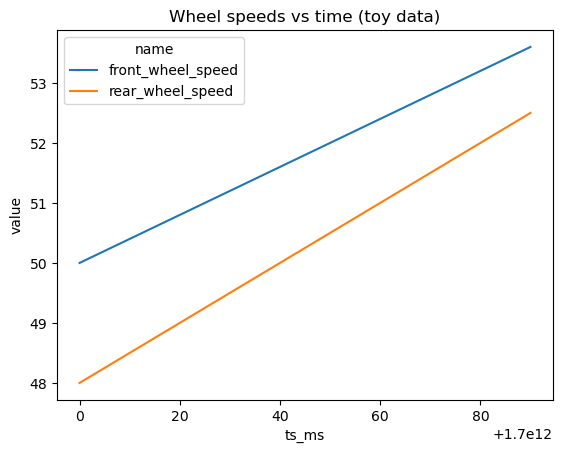

In [7]:
# 6) Bring results into Pandas and plot (optional)
query = """
SELECT sm.ts_ms, s.name, sm.value
FROM samples sm
JOIN sensors s ON s.sensor_id = sm.sensor_id
WHERE s.name IN ('front_wheel_speed','rear_wheel_speed')
ORDER BY sm.ts_ms, s.name;
"""
df = pd.read_sql_query(query, conn)

# Pivot to time-indexed wide table for fast plotting
wide = df.pivot(index="ts_ms", columns="name", values="value")
ax = wide.plot(title="Wheel speeds vs time (toy data)")
ax.set_xlabel("ts_ms")
ax.set_ylabel("value")

In [8]:
# 7) Reading in chunks (when tables are big)
# If your real table is huge, you can stream rows in chunks. This keeps memory usage under control:

query = """
SELECT sm.ts_ms, sm.sensor_id, sm.value
FROM samples sm
WHERE sm.ts_ms BETWEEN ? AND ?;
"""

chunks = pd.read_sql_query(query, conn, params=[start_ts, end_ts], chunksize=2000)

# Example: compute overall mean without loading everything at once
count = 0
total = 0.0
for chunk in chunks:
    total += chunk["value"].sum()
    count += chunk["value"].count()

overall_mean = total / count if count else None
overall_mean

1049.6333333333334

In [12]:
# 8) Create a small study database from a huge one
# When your real .db is massive, it’s often helpful to extract a subset (e.g., specific time range or specific sensors) into a new small file to iterate quickly.

import sqlite3
from pathlib import Path

def extract_subset_to_new_db(
    src_db_path: str,
    dst_db_path: str,
    start_ts_ms: int,
    end_ts_ms: int,
    sensor_names=None  # e.g. ['front_wheel_speed','rear_wheel_speed']
):
    # Ensure destination folder exists
    Path(dst_db_path).parent.mkdir(parents=True, exist_ok=True)

    # Connect to the **source** DB and ATTACH the destination
    con = sqlite3.connect(src_db_path)
    con.execute("PRAGMA foreign_keys = ON;")
    cur = con.cursor()

    try:
        # Attach destination as schema "dst"
        cur.execute("ATTACH DATABASE ? AS dst;", (dst_db_path,))

        # Start fresh: drop if exists in destination
        cur.execute("DROP TABLE IF EXISTS dst.samples;")
        cur.execute("DROP TABLE IF EXISTS dst.sensors;")

        if sensor_names:
            placeholders = ",".join(["?"] * len(sensor_names))
            # 1) Copy only selected sensors into dst
            cur.execute(f"""
                CREATE TABLE dst.sensors AS
                SELECT *
                FROM main.sensors
                WHERE name IN ({placeholders});
            """, sensor_names)

            # 2) Copy samples only for those sensors and within time window
            cur.execute("""
                CREATE TABLE dst.samples AS
                SELECT sm.*
                FROM main.samples sm
                JOIN dst.sensors s ON s.sensor_id = sm.sensor_id
                WHERE sm.ts_ms BETWEEN ? AND ?;
            """, (start_ts_ms, end_ts_ms))

        else:
            # Copy all sensors
            cur.execute("""
                CREATE TABLE dst.sensors AS
                SELECT * FROM main.sensors;
            """)
            # Copy samples within time window
            cur.execute("""
                CREATE TABLE dst.samples AS
                SELECT *
                FROM main.samples
                WHERE ts_ms BETWEEN ? AND ?;
            """, (start_ts_ms, end_ts_ms))

        # ✅ Create helpful indexes in destination (schema qualifier on the *index name*)
        cur.execute("CREATE INDEX IF NOT EXISTS dst.idx_samples_ts ON samples(ts_ms);")
        cur.execute("CREATE INDEX IF NOT EXISTS dst.idx_samples_sensor_ts ON samples(sensor_id, ts_ms);")

        con.commit()

    finally:
        # Best effort: detach even if something fails
        try:
            cur.execute("DETACH DATABASE dst;")
        except Exception:
            pass
        con.close()

In [13]:
# 9) DB Explorer: list tables, columns, 
def list_tables(conn):
    return pd.read_sql_query(
        "SELECT name, type FROM sqlite_master WHERE type IN ('table','view') ORDER BY name;",
        conn
    )

def table_info(conn, table):
    return pd.read_sql_query(f"PRAGMA table_info({table});", conn)

def index_info(conn, table):
    idx = pd.read_sql_query(f"PRAGMA index_list({table});", conn)
    details = []
    for _, row in idx.iterrows():
        cols = pd.read_sql_query(f"PRAGMA index_info({row['name']});", conn)
        details.append({"index_name": row["name"], "unique": row["unique"], "columns": cols["name"].tolist()})
    return pd.DataFrame(details)

def sample_rows(conn, table, n=5):
    return pd.read_sql_query(f"SELECT * FROM {table} LIMIT {n};", conn)

def approx_row_count(conn, table):
    # not exact but cheap for quick feel—COUNT(*) is exact but can be slow on huge tables
    return pd.read_sql_query(f"SELECT COUNT(*) AS cnt FROM {table};", conn).iloc[0,0]

# Try it:
list_tables(conn)

,name,type
0,samples,table
1,sensors,table


In [14]:
# Clean old subset if present (optional)
Path("mini_subset.db").unlink(missing_ok=True)

extract_subset_to_new_db(
    src_db_path="mini_telemetry.db",
    dst_db_path="mini_subset.db",
    start_ts_ms=start_ts,
    end_ts_ms=end_ts,
    sensor_names=["front_wheel_speed", "rear_wheel_speed"]
)

# Sanity-check the result
conn_subset = sqlite3.connect("mini_subset.db")
print(pd.read_sql_query("SELECT COUNT(*) AS rows_in_samples FROM samples;", conn_subset))
print(pd.read_sql_query("SELECT name, COUNT(*) AS n FROM sensors GROUP BY 1;", conn_subset))
conn_subset.close()


   rows_in_samples
0                6
                name  n
0  front_wheel_speed  1
1   rear_wheel_speed  1


### 10) Patterns you'll reuse on the real telemetry DB <br>
Filtering by time: WHERE ts_ms BETWEEN ? AND ? <br>
Filtering by signals: either by sensor_id IN (?, ?, …) or joining to a sensors table with name IN (…)<br>
Speed: add indexes on the columns you filter/join on (e.g., ts_ms, (sensor_id, ts_ms))<br>
Memory: stream rows with chunksize=; aggregate incrementally<br>
Explain: EXPLAIN QUERY PLAN <query> to confirm the index is used<br>
Explore: sqlite_master, PRAGMA table_info, PRAGMA index_list, quick LIMIT previews<br>
Safety: parameterize queries with ? placeholders; don’t format SQL with f-strings for user-provided values<br>
SQLite typing: types are flexible (type affinity). For numeric time-series, store numeric timestamps and REAL values; cast as needed in Pandas.<br>